# Efficient Permutation SHAP for Autoregressive Language Models

In the previous notebook, we implemented permutation SHAP and its forward/backward variant for token-level attribution in LLMs. In this notebook, we keep the same estimator and the same problem formulation, but focus on improving the computational efficiency of the method.

The main bottleneck of the previous implementation was the repeated evaluation of the value function, since each coalition required a separate call to the model. Here, we study a more efficient implementation based on three ideas: caching previously evaluated coalitions, evaluating multiple coalitions in batch, and reusing intermediate logits from longer token subsequences.

Therefore, the goal of this notebook is not to change the attribution method itself, but to optimize how the value function is computed in practice in the LLM setting.

## Problem setting 

We consider a tokenized prompt $x_{1:T}$ and a fixed target token $y$. Each token in the prompt is treated as a feature.

Given a subset of indices $S \subseteq \{1, \dots, T\}$, the corresponding coalition is constructed by selecting only the tokens in $S$, while always preserving their original order in the prompt.

The value function is defined as the log-probability of the target token given the coalition:
$$
v(S) = \log p(y \mid x_S)
$$

As in the previous notebook, the empty coalition is represented using the `eos_token_id` as a proxy input.

We use the forward/backward permutation SHAP estimator throughout the notebook. The exact reference is obtained by averaging this estimator over the full set of permutations.  We then compare the original and optimized implementations in two ways: first, by checking that they produce the same attributions when they use the same sampled permutations, and second, by comparing their computational cost.

## Limitations of the original implementation

In the original implementation, the value function $v(S)$ is evaluated at each step of every forward and backward trajectory.

This leads to a large number of model calls, many of which are redundant:
- the same coalitions (e.g., empty or full) are evaluated multiple times
- intermediate coalitions may repeat across permutations.

Since each evaluation requires a forward pass through the LLM, the cost is dominated by repeated model calls.

## Optimization idea

We avoid recomputing the same coalitions and reduce model calls by:
- caching evaluated coalitions,
- evaluating coalitions in batch,
- reusing prefix logits from maximal token subsequences.

The SHAP estimator itself remains unchanged.

## Setup and baseline implementation

We reuse the same setup as in the previous notebook.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import itertools
import math

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print("Device:", device)

c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2741.46it/s]


Device: cpu


In [3]:
prompt = "The capital of France is"
target = " Paris"

target_display = target.strip()

In [4]:
prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
target_ids = tokenizer(target, add_special_tokens=False)["input_ids"]

prompt_tokens = tokenizer.convert_ids_to_tokens(prompt_ids)
target_tokens = tokenizer.convert_ids_to_tokens(target_ids)

decoded_prompt_tokens = [tokenizer.decode([tid]).strip() for tid in prompt_ids]
decoded_target_tokens = [tokenizer.decode([tid]).strip() for tid in target_ids]

print("Prompt ids:", prompt_ids)
print("Prompt tokens:", prompt_tokens)
print("Target ids:", target_ids)
print("Target tokens:", target_tokens)
print("Decoded prompt tokens:", decoded_prompt_tokens)
print("Decoded target tokens:", decoded_target_tokens)

assert len(target_ids) == 1, "This notebook assumes that the target is a single token."

target_id = target_ids[0]

Prompt ids: [785, 6722, 315, 9625, 374]
Prompt tokens: ['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis']
Target ids: [12095]
Target tokens: ['ĠParis']
Decoded prompt tokens: ['The', 'capital', 'of', 'France', 'is']
Decoded target tokens: ['Paris']


In [5]:
def build_coalition_ids(prompt_ids, selected_indices):

  ordered_indices=sorted(selected_indices)
  coalition_ids = []

  for i in ordered_indices:
    coalition_ids.append(prompt_ids[i])

  return coalition_ids

In [6]:
def value_function(prompt_ids, selected_indices, target_id, model, device, tokenizer):

  coalition_ids=build_coalition_ids(prompt_ids, selected_indices)
  if len(coalition_ids)==0:
     # Use EOS token as a proxy for the empty coalition
    coalition_ids = [tokenizer.eos_token_id]

  input_tensor = torch.tensor([coalition_ids], device=device)

  model_inputs = {
      "input_ids": input_tensor,
      "attention_mask": torch.ones_like(input_tensor)
  }

  with torch.no_grad():
      outputs = model(**model_inputs)

  next_token_logits = outputs.logits[0, -1, :]
  next_token_logprobs = F.log_softmax(next_token_logits.float(), dim=-1)

  return next_token_logprobs[target_id].item()


### Original forward/backward implementation

For comparison purposes, we include the original forward/backward implementation used in the previous notebook. This version evaluates the value function at each step of the permutation paths.

In [7]:
def get_permutation_contributions(prompt_ids, permutation, target_id, model, device, tokenizer):

    T = len(prompt_ids)
    indices_coalition = []
    contributions = [0.0] * T

    v_before=value_function(prompt_ids, [], target_id, model, device, tokenizer)
    for j in permutation:

        v_after = value_function(prompt_ids, indices_coalition + [j], target_id, model, device, tokenizer)

        contributions[j] = v_after - v_before

        indices_coalition.append(j)
        v_before = v_after

    return contributions

In [8]:
def get_forward_backward_contributions(prompt_ids, permutation, target_id, model, device, tokenizer):
    T=len(prompt_ids)
    forward_contributions=[0.0]*T
    backward_contributions=[0.0]*T

    reverse_permutation=permutation[::-1]

    # forward contributions
    indices_coalition=[]
    v_before=value_function(prompt_ids, [], target_id, model, device, tokenizer)
    for j in permutation:
        
        v_after = value_function(prompt_ids, indices_coalition + [j], target_id, model, device, tokenizer)

        forward_contributions[j] = v_after - v_before

        indices_coalition.append(j)
        v_before = v_after


    # backward contributions
    indices_coalition=[]

    v_before=value_function(prompt_ids, [], target_id, model, device, tokenizer)
    for j in reverse_permutation:
        
        v_after = value_function(prompt_ids, indices_coalition + [j], target_id, model, device, tokenizer)

        backward_contributions[j] = v_after - v_before

        indices_coalition.append(j)
        v_before = v_after

    return forward_contributions, backward_contributions

In [9]:
def permutation_shap_forward_backward(prompt_ids, target_id, m, model, device, tokenizer, permutations=None):

    T = len(prompt_ids)
    shap_values = np.zeros(T)

    if permutations is None:
        permutations = [np.random.permutation(T) for _ in range(m)]
    else:
        m = len(permutations)  

    for permutation in permutations:
        
        forward_contributions, backward_contributions = get_forward_backward_contributions(prompt_ids, permutation, target_id, model, device, tokenizer)
        shap_values += np.array(forward_contributions) + np.array(backward_contributions)

    shap_values /= (2 * m)

    return shap_values

We now move to the optimized implementation. As mentioned, instead of evaluating the value function along each permutation path, we first separate the combinatorial structure of the algorithm from the model evaluations.

## Caching implementation

### Forward and backward coalition paths

We first separate the combinatorial part of the algorithm.  Given a permutation, we generate the sequence of coalitions along the forward and backward paths, without evaluating the model.

In [10]:
def get_forward_backward_coalitions(permutation):

    # Forward
    forward_coalitions = [tuple()]
    current = []
    
    for j in permutation:
        current = sorted(current + [j])
        forward_coalitions.append(tuple(current))

    # Backward 
    backward_coalitions = [tuple()]
    current = []

    for j in permutation[::-1]:
        current = sorted(current + [j])
        backward_coalitions.append(tuple(current))

    return forward_coalitions, backward_coalitions

### Collecting required coalitions

We collect all coalitions appearing in the forward and backward paths of the sampled permutations, while preserving the path structure.

Coalitions are used for evaluation, and paths are used later to reconstruct the forward/backward contributions.

In [11]:
def collect_all_coalitions_and_paths(permutations):
    all_paths=[]
    all_coalitions=set()

    for permutation in permutations:
        forward_coalitions, backward_coalitions = get_forward_backward_coalitions(permutation)
        all_paths.append((forward_coalitions, backward_coalitions))

        all_coalitions.update(forward_coalitions)
        all_coalitions.update(backward_coalitions)

    return all_paths, all_coalitions


### Caching coalition values

Once all required coalitions have been collected, we evaluate each coalition only once and store its value.

This cache will later be reused to reconstruct the forward and backward contributions without additional model calls.

In [12]:
def build_coalition_cache(all_coalitions, prompt_ids, target_id, model, device, tokenizer):
    coalition_cache={}
    
    for coalition in all_coalitions:
        value=value_function(prompt_ids, coalition, target_id, model, device, tokenizer)
        coalition_cache[coalition]=value

    return coalition_cache

### Reconstructing forward and backward contributions

Once the coalition values have been cached, the forward and backward contributions can be recovered without further model evaluations.

Each marginal contribution is obtained as the difference between two consecutive coalition values along the corresponding path.

In [13]:
def reconstruct_from_cache(all_paths,  permutations,  coalition_cache):
    T=len(permutations[0])
    shap_values=np.zeros(T)

    for permutation, (forward_coalitions, backward_coalitions) in zip (permutations, all_paths):
        forward_contributions=np.zeros(T)
        backward_contributions=np.zeros(T)

        for k in range(1, len(permutation)+1):
            j=permutation[k-1]
            value_before=coalition_cache[forward_coalitions[k-1]]
            value_after=coalition_cache[forward_coalitions[k]]
            forward_contributions[j]=value_after-value_before

        reverse_permutation=permutation[::-1]

        for k in range(1, len(reverse_permutation)+1):
            j=reverse_permutation[k-1]
            value_before=coalition_cache[backward_coalitions[k-1]]
            value_after=coalition_cache[backward_coalitions[k]]
            backward_contributions[j]=value_after-value_before

        shap_values+=forward_contributions+backward_contributions
    
    shap_values=shap_values/(2*len(permutations))

    return shap_values

### Optimized forward/backward permutation SHAP

We combine the previous steps into a single function.  
The estimator remains unchanged, but coalition values are computed once and reused through a cache.

In [14]:
def permutation_shap_forward_backward_cached(prompt_ids, target_id, m, model, device, tokenizer, permutations=None):

    T=len(prompt_ids)

    if permutations is None:
        permutations=[np.random.permutation(T) for _ in range(m)]
    else:
        m=len(permutations)

    all_paths, all_coalitions = collect_all_coalitions_and_paths(permutations)

    coalition_cache=build_coalition_cache(all_coalitions, prompt_ids, target_id, model, device, tokenizer)

    shap_values=reconstruct_from_cache(all_paths, permutations, coalition_cache)

    return shap_values

### Caching efficiency intuition

For $m$ sampled permutations and a prompt of length $T$, the original implementation evaluates the value function
$$
2m(T+1)
$$
times, since each permutation requires $T+1$ evaluations along the forward path and $T+1$ along the backward path.

In the optimized version, each coalition is evaluated only once, so the cost is
$$
|\mathrm{all\_coalitions}|.
$$
Since coalitions are subsets of the $T$ token indices, we always have
$$
|\mathrm{all\_coalitions}| \le 2^T.
$$

A full quantitative comparison is provided in the final section.

## Batching for efficient coalition evaluation

The cache-based optimization already reduces the number of repeated value function evaluations by computing each coalition only once. However, coalition values are still evaluated one by one, which leads to many separate forward passes through the model.

To make the implementation more efficient, we now evaluate coalition values in mini-batches. Since each coalition corresponds to a variable-length token subsequence, the sequences in each batch are padded to the same length and processed together with an attention mask.

This modification does not change the estimator itself. It only changes how the coalition cache is filled, reducing the number of model calls and improving hardware utilization, especially on GPU.

### Building the coalition cache with batching

Instead of evaluating each coalition separately, we group several coalitions into a mini-batch and process them in a single forward pass through the model. As mentioned, because coalition sequences may have different lengths, they are padded to the same size and accompanied by an attention mask.

As in the cache-based version, each coalition is still evaluated only once. The only difference is that these evaluations are now performed in batches, making the process more efficient.

In [15]:
def build_coalition_cache_batched(all_coalitions, prompt_ids, target_id, model, device, tokenizer, batch_size=32):
    coalition_cache = {}
    coalitions = list(all_coalitions)

    for start in range(0, len(coalitions), batch_size):
        batch_coalitions = coalitions[start:start + batch_size]

        batch_ids = []
        lengths = []

        for coalition in batch_coalitions:
            coalition_ids = build_coalition_ids(prompt_ids, coalition)

            if len(coalition_ids) == 0:
                coalition_ids = [tokenizer.eos_token_id]

            batch_ids.append(coalition_ids)
            lengths.append(len(coalition_ids))

        max_len = max(lengths)

        padded_ids = []
        attention_masks = []

        for coalition_ids in batch_ids:
            pad_len = max_len - len(coalition_ids)
            padded_ids.append(coalition_ids + [tokenizer.eos_token_id] * pad_len)
            attention_masks.append([1] * len(coalition_ids) + [0] * pad_len)

        input_tensor = torch.tensor(padded_ids, device=device)
        attention_mask = torch.tensor(attention_masks, device=device)
        last_positions = torch.tensor([length - 1 for length in lengths], device=device)

        model_inputs = {
            "input_ids": input_tensor,
            "attention_mask": attention_mask
        }

        with torch.no_grad():
            outputs = model(**model_inputs)

        # torch.arange(len(batch_coalitions) for row indices (one per sequence) used to extract the last valid logits of each coalition
        next_token_logits = outputs.logits[torch.arange(len(batch_coalitions), device=device),last_positions,:]
        next_token_logprobs = F.log_softmax(next_token_logits.float(), dim=-1)
        target_logprobs = next_token_logprobs[:, target_id].detach().cpu().numpy()

        for coalition, value in zip(batch_coalitions, target_logprobs):
            coalition_cache[coalition] = float(value)

    return coalition_cache

### Batched permutation SHAP (forward/backward)

Once the coalition cache can be built in batches, the forward/backward permutation SHAP pipeline remains essentially unchanged. We still collect all coalitions appearing across the sampled permutations, evaluate each unique coalition only once, and reconstruct the SHAP values from the cached results.

The only modification is that the coalition cache is now filled with the batched function introduced above.

In [16]:
def permutation_shap_forward_backward_batched(prompt_ids, target_id, m, model, device, tokenizer, permutations=None, batch_size=32):
    
    if permutations is None:
        permutations = [np.random.permutation(len(prompt_ids)) for _ in range(m)]
    else:
        m = len(permutations)

    all_paths, all_coalitions = collect_all_coalitions_and_paths(permutations)

    coalition_cache = build_coalition_cache_batched(all_coalitions, prompt_ids, target_id, model, device, tokenizer, batch_size=batch_size)

    shap_values = reconstruct_from_cache(all_paths, permutations, coalition_cache)

    return shap_values

### Batching efficiency intuition

Batching does not reduce the number of value function evaluations, since each coalition is still evaluated exactly once:

$$
|\mathrm{all\_coalitions}|
$$

However, it reduces the number of forward passes through the model by grouping multiple coalitions into a single batch.

If a batch size of $B$ is used, the number of forward passes becomes:

$$
\left\lceil \frac{|\mathrm{all\_coalitions}|}{B} \right\rceil
$$

instead of one forward pass per coalition. This can lead to better hardware utilization and improved runtime, especially
when using GPUs. On CPU, the benefit may depend on the model, batch size, and
padding overhead.

A full quantitative comparison is provided in the final section.

## Prefix reuse for coalition evaluation

The previous cached implementation evaluates each unique coalition once. The batched version reduces the number of model calls by processing several coalitions together.

We now introduce another optimization that exploits an autoregressive property of causal language models: a single forward pass over a sequence gives logits for all intermediate prefixes.

Therefore, if several required coalitions produce token subsequences that are prefixes of a longer subsequence, we only need to run the model on the longest sequence. The values of the shorter coalitions can be recovered from the intermediate logits.

Additionally, different coalitions may produce the same token subsequence (e.g., when the prompt contains repeated tokens). In that case, a single model evaluation is reused for all of them.

### Mapping coalitions to token subsequences

Coalitions are still represented as tuples of prompt-token indices, exactly as in the previous implementations.

For prefix reuse, we also need to know which actual token subsequence each coalition sends to the model. Note that multiple coalitions may map to the same subsequence, so this relationship is not necessarily one-to-one.

In [17]:
def build_sequence_to_coalitions(all_coalitions, prompt_ids):

    sequence_to_coalitions = {}

    for coalition in all_coalitions:
        if len(coalition) == 0:
            continue

        # Reuse the existing helper to convert prompt positions into token ids
        coalition_ids = tuple(build_coalition_ids(prompt_ids, coalition))

        # Different coalitions can produce the same token subsequence
        if coalition_ids not in sequence_to_coalitions:
            sequence_to_coalitions[coalition_ids] = []

        # Keep all coalitions so the final cache can still use coalition keys
        sequence_to_coalitions[coalition_ids].append(coalition)

    return sequence_to_coalitions

### Selecting maximal token subsequences

A token subsequence is maximal if it is not a prefix of any other required subsequence.

Only maximal subsequences will require a model forward pass. Values for shorter required prefixes can later be recovered from the intermediate logits of these maximal sequences.

In [18]:
def is_prefix(short_sequence, long_sequence):

    if len(short_sequence) >= len(long_sequence):
        return False

    return long_sequence[:len(short_sequence)] == short_sequence


def get_maximal_sequences(sequences):
    maximal_sequences = []

    for sequence in sequences:
        is_prefix_of_longer_sequence = False

        for other_sequence in sequences:
            if is_prefix(sequence, other_sequence):
                is_prefix_of_longer_sequence = True
                break

        if not is_prefix_of_longer_sequence:
            maximal_sequences.append(sequence)

    return maximal_sequences

### Building the coalition cache with prefix reuse

We now build the same `coalition -> value` cache used in the previous implementations.

Instead of evaluating each coalition independently, we only run the model on maximal token subsequences. The values for shorter coalitions are recovered from the intermediate logits corresponding to their prefixes.

The empty coalition is handled separately, as before.

In [19]:
def build_coalition_cache_prefix_reuse(all_coalitions, prompt_ids, target_id, model, device, tokenizer):
    coalition_cache = {}

    # Empty coalition is handled as in the previous cache builders
    if tuple() in all_coalitions:
        coalition_cache[tuple()] = value_function(prompt_ids, tuple(), target_id, model, device, tokenizer)

    # Group coalitions by the token subsequence they produce
    sequence_to_coalitions = build_sequence_to_coalitions(all_coalitions, prompt_ids)
    sequences = list(sequence_to_coalitions.keys())

    # Keep only sequences that are not prefixes of longer required sequences
    maximal_sequences = get_maximal_sequences(sequences)

    # Use a deterministic order and avoid overwriting already evaluated prefixes
    maximal_sequences = sorted(maximal_sequences, key=lambda sequence: (len(sequence), sequence))
    evaluated_prefixes = set()

    # Evaluate only maximal sequences
    for sequence in maximal_sequences:
        input_ids = torch.tensor([list(sequence)], device=device)
        attention_mask = torch.ones_like(input_ids)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # logits[k - 1] gives the prediction after seeing sequence[:k]
        logits = outputs.logits[0]
        logprobs = F.log_softmax(logits.float(), dim=-1)

        # Recover values for all required prefixes of this maximal sequence
        for k in range(1, len(sequence) + 1):
            prefix = sequence[:k]

            if prefix not in sequence_to_coalitions or prefix in evaluated_prefixes:
                continue

            value = logprobs[k - 1, target_id].item()

            # Store values with coalition keys, as expected by reconstruction
            for coalition in sequence_to_coalitions[prefix]:
                coalition_cache[coalition] = value

            evaluated_prefixes.add(prefix)

    return coalition_cache

### Prefix-reuse forward/backward permutation SHAP

The SHAP estimator is kept unchanged: we still use the same forward/backward coalition paths and the same reconstruction step.

The only change is how the `coalition -> value` cache is built. Instead of evaluating each coalition independently, the cache is filled using prefix reuse.

In [20]:
def permutation_shap_forward_backward_prefix_reuse(prompt_ids, target_id, m, model, device, tokenizer, permutations=None):
    if permutations is None:
        permutations = [np.random.permutation(len(prompt_ids)) for _ in range(m)]
    else:
        m = len(permutations)

    # Collect the same forward/backward paths and coalitions as in the cached version
    all_paths, all_coalitions = collect_all_coalitions_and_paths(permutations)

    # Build the coalition cache using prefix reuse
    coalition_cache = build_coalition_cache_prefix_reuse(all_coalitions, prompt_ids, target_id, model, device, tokenizer)

    # Reconstruct SHAP values from the cached coalition values
    shap_values = reconstruct_from_cache(all_paths, permutations, coalition_cache)

    return shap_values

## Final comparison including prefix reuse

We now compare all forward/backward SHAP implementations under a single reproducible setup.

All methods will use the same prompt, target token, model, device, and sampled permutations. Therefore, differences in runtime or computational cost come from the implementation strategy, not from a different estimator.

We also compute an exact forward/backward SHAP baseline by averaging over all permutations. This is feasible here because the prompt is short. The exact baseline will be used only to measure sampling error.

### Experimental setup and exact baseline

We first define the full permutation set, fix the random seed used to select sampled permutations, and compute the exact forward/backward SHAP baseline.

The exact baseline is computed with the original forward/backward implementation by averaging over all permutations. This provides the clearest reference point for evaluating sampling error.

In [21]:
T = len(prompt_ids)

all_permutations = [np.array(p) for p in itertools.permutations(range(T))]
M = len(all_permutations)

seed = 42
rng = np.random.default_rng(seed)
rng.shuffle(all_permutations)

m = 10
sampled_permutations = all_permutations[:m]

batch_size = 5
num_repeats = 3

shap_fb_exact = permutation_shap_forward_backward(
    prompt_ids, target_id, M, model, device, tokenizer, permutations=all_permutations
)

print("Prompt length T:", T)
print("Total permutations:", M)
print("Random seed:", seed)
print("Sampled permutations m:", m)
print("Batch size:", batch_size)
print("Runtime repeats:", num_repeats)
print("Exact forward/backward SHAP baseline:")
print(shap_fb_exact)

Prompt length T: 5
Total permutations: 120
Random seed: 42
Sampled permutations m: 10
Batch size: 5
Runtime repeats: 3
Exact forward/backward SHAP baseline:
[2.17969621 3.04598797 3.64657152 4.96684139 2.0502023 ]


### Numerical equivalence

We now run all implementations on the same sampled permutations.

The cached, batched, and prefix-reuse versions should produce the same SHAP
values up to small numerical differences, because they do not change the
estimator; they only change how coalition values are evaluated.

The error against `shap_fb_exact` measures sampling error, not implementation error.

In [22]:
methods = {
    "Original": lambda: permutation_shap_forward_backward(prompt_ids, target_id, m, model, device, tokenizer, permutations=sampled_permutations),
    "Cached": lambda: permutation_shap_forward_backward_cached(prompt_ids, target_id, m, model, device, tokenizer, permutations=sampled_permutations),
    "Batched": lambda: permutation_shap_forward_backward_batched(prompt_ids, target_id, m, model, device, tokenizer, permutations=sampled_permutations, batch_size=batch_size),
    "Prefix reuse": lambda: permutation_shap_forward_backward_prefix_reuse(prompt_ids, target_id, m, model, device, tokenizer, permutations=sampled_permutations)
}

shap_results = {}

for name, method in methods.items():
    shap_results[name] = method()

In [23]:
atol = 3e-2
rtol = 1e-4

reference = shap_results["Original"]

numerical_comparison = pd.DataFrame([
    {
        "Implementation": name,
        "Matches original within tolerance": np.allclose(values, reference, atol=atol, rtol=rtol),
        "Max abs diff vs original": np.max(np.abs(values - reference)),
        "L2 error vs exact baseline": np.linalg.norm(values - shap_fb_exact)
    }
    for name, values in shap_results.items()
])

numerical_comparison

,Implementation,Matches original within tolerance,Max abs diff vs original,L2 error vs exact baseline
0,Original,True,0.000000,0.938395
1,Cached,True,0.000000,0.938395
2,Batched,True,0.007389,0.930955
3,Prefix reuse,True,0.002668,0.936746


### Structural efficiency

The previous table checks numerical equivalence. We now compare the structural cost of each implementation.

The original implementation evaluates the value function every time a coalition appears in a forward or backward path.

The cached implementation evaluates each unique coalition only once.

The batched implementation evaluates the same unique coalitions as the cached version, but groups them into fewer model forward calls.

The prefix-reuse implementation evaluates only maximal non-empty token subsequences and recovers shorter required prefixes from intermediate logits.

In [24]:
all_paths, all_coalitions = collect_all_coalitions_and_paths(sampled_permutations)

sequence_to_coalitions = build_sequence_to_coalitions(all_coalitions, prompt_ids)
sequences = list(sequence_to_coalitions.keys())
maximal_sequences = get_maximal_sequences(sequences)

num_original_evaluations = 2 * m * (T + 1)

num_unique_coalitions = len(all_coalitions)
num_empty_coalition = 1 if tuple() in all_coalitions else 0
num_non_empty_coalitions = num_unique_coalitions - num_empty_coalition

num_unique_non_empty_sequences = len(sequences)
num_maximal_sequences = len(maximal_sequences)

num_duplicate_sequence_savings = num_non_empty_coalitions - num_unique_non_empty_sequences
num_prefix_reuse_savings = num_unique_non_empty_sequences - num_maximal_sequences
num_total_prefix_savings = num_non_empty_coalitions - num_maximal_sequences

In [25]:
efficiency_comparison = pd.DataFrame([
    {
        "Implementation": "Original",
        "Model inputs evaluated": num_original_evaluations,
        "Model forward calls": num_original_evaluations,
        "Description": "Repeated value-function evaluations"
    },
    {
        "Implementation": "Cached",
        "Model inputs evaluated": num_unique_coalitions,
        "Model forward calls": num_unique_coalitions,
        "Description": "One evaluation per unique coalition"
    },
    {
        "Implementation": "Batched",
        "Model inputs evaluated": num_unique_coalitions,
        "Model forward calls": math.ceil(num_unique_coalitions / batch_size),
        "Description": "Same coalitions as cached, grouped into batches"
    },
    {
        "Implementation": "Prefix reuse",
        "Model inputs evaluated": num_maximal_sequences + num_empty_coalition,
        "Model forward calls": num_maximal_sequences + num_empty_coalition,
        "Description": "Only maximal subsequences plus empty coalition"
    }
])

efficiency_comparison["Forward-call reduction vs original"] = (
    num_original_evaluations / efficiency_comparison["Model forward calls"]
)

efficiency_comparison

,Implementation,Model inputs evaluated,Model forward calls,Description,Forward-call reduction vs original
0,Original,120,120,Repeated value-function evaluations,1.000000
1,Cached,28,28,One evaluation per unique coalition,4.285714
2,Batched,28,6,"Same coalitions as cached, grouped into batches",20.000000
3,Prefix reuse,16,16,Only maximal subsequences plus empty coalition,7.500000


In [26]:
print("Prefix-reuse breakdown")
print("----------------------")
print("Unique coalitions:", num_unique_coalitions)
print("Empty coalition:", num_empty_coalition)
print("Non-empty unique coalitions:", num_non_empty_coalitions)
print("Unique non-empty token subsequences:", num_unique_non_empty_sequences)
print("Maximal token subsequences:", num_maximal_sequences)
print("Savings from duplicated token subsequences:", num_duplicate_sequence_savings)
print("Savings from prefix reuse:", num_prefix_reuse_savings)
print("Total non-empty savings vs cached:", num_total_prefix_savings)

Prefix-reuse breakdown
----------------------
Unique coalitions: 28
Empty coalition: 1
Non-empty unique coalitions: 27
Unique non-empty token subsequences: 27
Maximal token subsequences: 15
Savings from duplicated token subsequences: 0
Savings from prefix reuse: 12
Total non-empty savings vs cached: 12


### Runtime comparison

We now measure runtime for all sampled implementations.

The exact baseline is not included here because it uses all permutations and answers a different question. Runtime is compared only for methods using the same `sampled_permutations`.

Each method is run several times and we report the mean and standard deviation. When using GPU, CUDA synchronization is applied before and after each timed run.

In [27]:
def sync_device():
    if "cuda" in str(device):
        torch.cuda.synchronize()


def time_method(method, repeats=3):
    times = []

    # Warm-up run
    sync_device()
    _ = method()
    sync_device()

    for _ in range(repeats):
        sync_device()
        start = time.perf_counter()
        _ = method()
        sync_device()
        times.append(time.perf_counter() - start)

    return np.mean(times), np.std(times)

In [28]:
runtime_rows = []

for name, method in methods.items():
    mean_time, std_time = time_method(method, repeats=num_repeats)

    runtime_rows.append({
        "Implementation": name,
        "Mean runtime (s)": mean_time,
        "Std runtime (s)": std_time
    })

runtime_comparison = pd.DataFrame(runtime_rows)
runtime_comparison["Speedup vs original"] = runtime_comparison.loc[0, "Mean runtime (s)"] / runtime_comparison["Mean runtime (s)"]

runtime_comparison

,Implementation,Mean runtime (s),Std runtime (s),Speedup vs original
0,Original,31.328839,2.886348,1.000000
1,Cached,6.715816,0.454606,4.664934
2,Batched,7.047664,0.371792,4.445280
3,Prefix reuse,3.842494,0.164944,8.153257


## Convergence to the exact SHAP baseline

Finally, we study how the SHAP estimates evolve as the number of sampled
permutations increases.

We use the prefix-reuse implementation because it is the main optimization
introduced in this notebook and preserves the same forward/backward SHAP
estimator up to small numerical differences.

We analyze convergence in two ways:

1. Global convergence, using the L2 error against `shap_fb_exact`.
2. Token-wise convergence, showing how each token attribution approaches its exact SHAP value.

When all permutations are used, any remaining difference with respect to
`shap_fb_exact` is due to numerical differences between implementations, not to
sampling error.

In [29]:
m_values = [1, 2, 5, 10, 20, 40, 80, M]
m_values = [m_value for m_value in m_values if m_value <= M]

convergence_rows = []
token_convergence_rows = []

prompt_token_labels = [
    tokenizer.decode([token_id]).strip() or tokenizer.decode([token_id])
    for token_id in prompt_ids
]

for m_value in m_values:
    permutations_m = all_permutations[:m_value]

    shap_m = permutation_shap_forward_backward_prefix_reuse(
        prompt_ids, target_id, m_value, model, device, tokenizer, permutations=permutations_m
    )

    convergence_rows.append({
        "m": m_value,
        "L2 error vs exact baseline": np.linalg.norm(shap_m - shap_fb_exact),
        "Max abs error vs exact baseline": np.max(np.abs(shap_m - shap_fb_exact))
    })

    for token_idx, token_label in enumerate(prompt_token_labels):
        token_convergence_rows.append({
            "m": m_value,
            "Token index": token_idx,
            "Token": token_label,
            "SHAP value": shap_m[token_idx],
            "Exact SHAP value": shap_fb_exact[token_idx],
            "Abs error": abs(shap_m[token_idx] - shap_fb_exact[token_idx])
        })

convergence_comparison = pd.DataFrame(convergence_rows)
token_convergence = pd.DataFrame(token_convergence_rows)

convergence_comparison

,m,L2 error vs exact baseline,Max abs error vs exact baseline
0,1,4.631461,3.461621
1,2,1.762374,1.197688
2,5,1.101418,0.641701
3,10,0.936746,0.624316
4,20,0.918704,0.581115
5,40,0.666955,0.531438
6,80,0.615953,0.480358
7,120,0.001926,0.001220


### Global convergence curve

The following plot shows how the global error decreases as more permutations are included in the estimator.

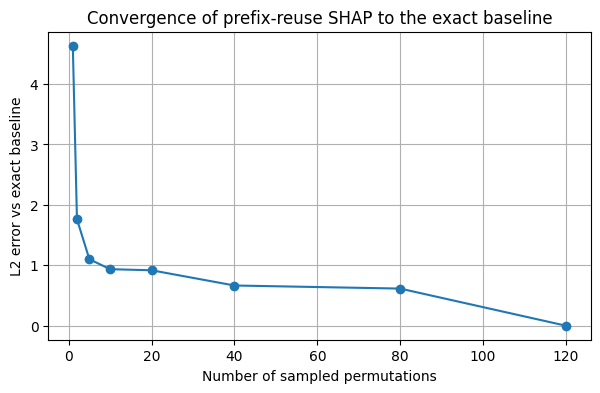

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(
    convergence_comparison["m"],
    convergence_comparison["L2 error vs exact baseline"],
    marker="o"
)

plt.xlabel("Number of sampled permutations")
plt.ylabel("L2 error vs exact baseline")
plt.title("Convergence of prefix-reuse SHAP to the exact baseline")
plt.grid(True)
plt.show()

### Token-wise convergence

The following plot shows how the attribution assigned to each prompt token evolves as the number of sampled permutations increases.

Dashed horizontal lines represent the exact SHAP value for each token.

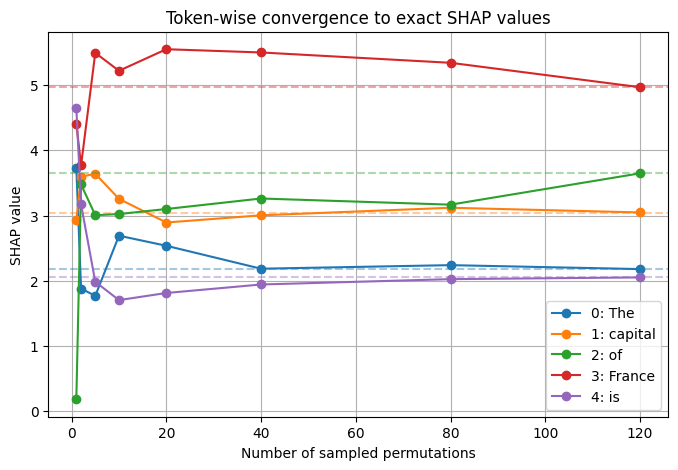

In [31]:
plt.figure(figsize=(8, 5))

for token_idx, token_label in enumerate(prompt_token_labels):
    token_data = token_convergence[token_convergence["Token index"] == token_idx]

    line = plt.plot(
        token_data["m"],
        token_data["SHAP value"],
        marker="o",
        label=f"{token_idx}: {token_label}"
    )[0]

    plt.axhline(
        shap_fb_exact[token_idx],
        linestyle="--",
        alpha=0.4,
        color=line.get_color()
    )

plt.xlabel("Number of sampled permutations")
plt.ylabel("SHAP value")
plt.title("Token-wise convergence to exact SHAP values")
plt.grid(True)
plt.legend()
plt.show()